DIPSTICK CALIBRATION:
  50L |  10.00 cm
 100L |  20.00 cm
 150L |  30.00 cm
 200L |  40.00 cm
 250L |  50.00 cm
 300L |  60.00 cm
 350L |  70.00 cm
 400L |  80.00 cm
 450L |  90.00 cm
 500L | 100.00 cm
 550L | 110.00 cm
 600L | 120.00 cm
 650L | 130.00 cm
 700L | 140.00 cm
 750L | 150.00 cm
 800L | 160.00 cm
 850L | 170.00 cm
 900L | 180.00 cm
 950L | 190.00 cm
1000L | 200.00 cm


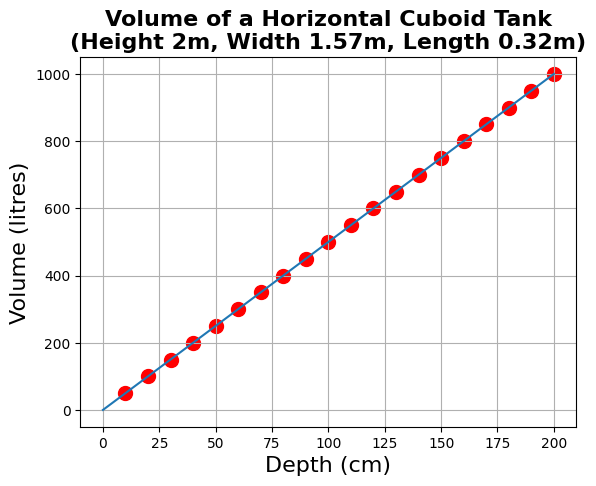

In [1]:
#Cube Dipstick Callibration


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
import scipy.stats

n = np.linspace(0.0, 2.0, 1000)
l = 1/np.pi
w = np.pi / 2

def cube_volume(h, w, l):
    return l*w*h

a = np.zeros(1000)
for i in range(1000):

    a[i] = cube_volume(n[i], w, l)

cube_depth_from_volume = interp1d(a, n)




target_volumes = np.arange(50, 1001, 50) / 1000
cube_dipstick_depths = cube_depth_from_volume(target_volumes)


# calibration table
print("DIPSTICK CALIBRATION:")
for vol, depth in zip(range(50, 1001, 50), cube_dipstick_depths):
    print(f"{vol:4}L | {depth*100:6.2f} cm")


# Plot
plt.plot(n*100, a*1000)
plt.scatter(cube_dipstick_depths*100, target_volumes*1000, color='red', s=100)
plt.title(f"Volume of a Horizontal Cuboid Tank\n(Height 2m, Width {w:.2f}m, Length {l:.2f}m)",fontsize=16,fontweight='bold')
plt.xlabel('Depth (cm)',fontsize=16)
plt.ylabel('Volume (litres)',fontsize=16)
plt.grid(True)
plt.savefig("dipstick_calibration_cuboid.pdf", format="pdf")
plt.show()

In [3]:
#Cube Dipstick Error


target_volumes_litres = np.arange(50, 1001, 50)
target_volumes = np.arange(50, 1001, 50) / 1000


# Reading error: ±0.5 cm in depth measurement
reading_error_cm = 0.5
reading_error_m = reading_error_cm / 100


print(f"\nAssuming dipstick reading error of \u00b1{reading_error_cm} cm:\n")
print(f"{'Volume':>10} | {'Depth':>10} | {'\u0394V (litres)':>15} | {'% Error':>10}")
print("-" * 52)

cube_volume_errors = []
for vol, depth in zip(target_volumes_litres, cube_dipstick_depths ):

    V_plus = cube_volume(depth + reading_error_m, w, l) * 1000
    V_minus = cube_volume(depth - reading_error_m, w, l) * 1000
    error_litres = max(abs(V_plus - vol), abs(V_minus - vol))
    error_percent = (error_litres / vol) * 100
    cube_volume_errors.append(error_litres)
    print(f"{vol:>10.0f}L | {depth*100:>9.2f}cm | \u00b1{error_litres:>12.2f} | {error_percent:>9.2f}%")


Assuming dipstick reading error of ±0.5 cm:

    Volume |      Depth |     ΔV (litres) |    % Error
----------------------------------------------------
        50L |     10.00cm | ±        2.50 |      5.00%
       100L |     20.00cm | ±        2.50 |      2.50%
       150L |     30.00cm | ±        2.50 |      1.67%
       200L |     40.00cm | ±        2.50 |      1.25%
       250L |     50.00cm | ±        2.50 |      1.00%
       300L |     60.00cm | ±        2.50 |      0.83%
       350L |     70.00cm | ±        2.50 |      0.71%
       400L |     80.00cm | ±        2.50 |      0.62%
       450L |     90.00cm | ±        2.50 |      0.56%
       500L |    100.00cm | ±        2.50 |      0.50%
       550L |    110.00cm | ±        2.50 |      0.45%
       600L |    120.00cm | ±        2.50 |      0.42%
       650L |    130.00cm | ±        2.50 |      0.38%
       700L |    140.00cm | ±        2.50 |      0.36%
       750L |    150.00cm | ±        2.50 |      0.33%
       800L |    160.

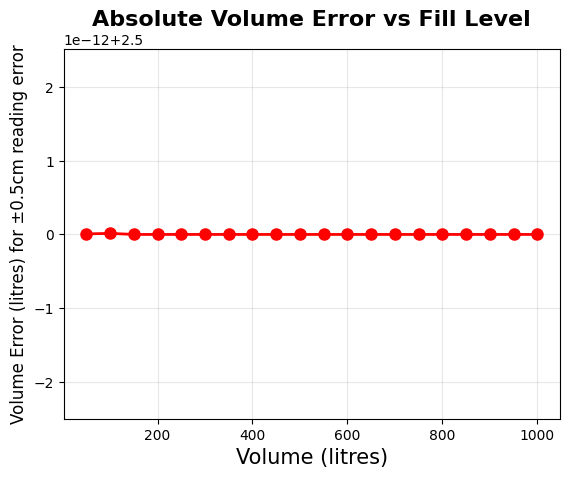

In [4]:
#Cube Absolute Error

plt.plot(target_volumes_litres, cube_volume_errors, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Volume (litres)', fontsize=15)
plt.ylabel('Volume Error (litres) for ±0.5cm reading error', fontsize=12)
plt.title('Absolute Volume Error vs Fill Level', fontsize=16, fontweight='bold')
plt.savefig("Absolute_Volume_Error.pdf", format="pdf")
plt.grid(True, alpha=0.3)

In [6]:
#Cube Error Multiple Trials

import scipy.stats as stats
n_readings = 3

#this simulates a human reading the dipstick accounting for random error in the reading
def cube_simulate_readings(true_depth, n_readings, error_std):
    error_std_m = error_std / 100
    readings = np.random.normal(true_depth, error_std_m, n_readings)
    return readings

#converts the depth into a volume
def cube_calculate_volume_from_readings(depth_readings, r, l):
    cube_volumes = []
    for depth in depth_readings:

        if depth < 0:
            depth = 0
        if depth > 2*r:
            depth = 2*r
        vol = cube_volume(depth, w, l) * 1000  # in litres
        cube_volumes.append(vol)
    return np.array(cube_volumes)


print("\nCOMPARISON: Single Reading vs Multiple Readings (Average)")
print("="*70)

# Run simulation for each calibration mark
np.random.seed(42)  # For reproducibility

single_reading_errors = []
multiple_reading_errors = []
confidence_intervals_95 = []

#finds the error for  a single reading and 5 readings and calculates how wrong it was
for true_vol, true_depth in zip(target_volumes_litres, cube_dipstick_depths):

    single_depth = cube_simulate_readings(true_depth, 1, reading_error_cm)[0]
    single_volume = cube_calculate_volume_from_readings([single_depth], 1, l)[0]
    single_error = abs(single_volume - true_vol)
    single_reading_errors.append(single_error)


    multiple_depths = cube_simulate_readings(true_depth, n_readings, reading_error_cm)
    average_depth = np.mean(multiple_depths)
    average_volume = cube_calculate_volume_from_readings([average_depth], 1, l)[0]
    multiple_error = abs(average_volume - true_vol)
    multiple_reading_errors.append(multiple_error)


    all_volumes = cube_calculate_volume_from_readings(multiple_depths, 1, l)


    ci_95 = stats.t.interval(0.95, len(all_volumes)-1,
                              loc=np.mean(all_volumes),
                              scale=stats.sem(all_volumes))
    ci_width = ci_95[1] - ci_95[0]
    confidence_intervals_95.append(ci_width)

print(f"{'Volume':>8} | {'True Depth':>12} | {'Single Error':>13} | {'Avg Error':>11} | {'Improvement':>12}")
print("-"*70)
for i, vol in enumerate(target_volumes_litres):
    improvement = (1 - multiple_reading_errors[i]/single_reading_errors[i]) * 100
    print(f"{vol:>8}L | {cube_dipstick_depths[i]*100:>11.2f}cm | {single_reading_errors[i]:>12.2f}L | {multiple_reading_errors[i]:>10.2f}L | {improvement:>11.1f}%")


COMPARISON: Single Reading vs Multiple Readings (Average)
  Volume |   True Depth |  Single Error |   Avg Error |  Improvement
----------------------------------------------------------------------
      50L |       10.00cm |         1.24L |       1.69L |       -36.4%
     100L |       20.00cm |         0.59L |       1.76L |      -200.7%
     150L |       30.00cm |         1.17L |       0.32L |        72.6%
     200L |       40.00cm |         0.60L |       3.50L |      -478.7%
     250L |       50.00cm |         2.53L |       1.67L |        34.0%
     300L |       60.00cm |         3.66L |       1.32L |        64.0%
     350L |       70.00cm |         1.36L |       0.55L |        59.3%
     400L |       80.00cm |         1.50L |       0.80L |        46.8%
     450L |       90.00cm |         0.03L |       1.21L |     -3495.8%
     500L |      100.00cm |         0.52L |       2.58L |      -393.3%
     550L |      110.00cm |         1.85L |       0.20L |        88.9%
     600L |      120

/tmp/ipython-input-949/3646038478.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  improvement = (1 - multiple_reading_errors[i]/single_reading_errors[i]) * 100


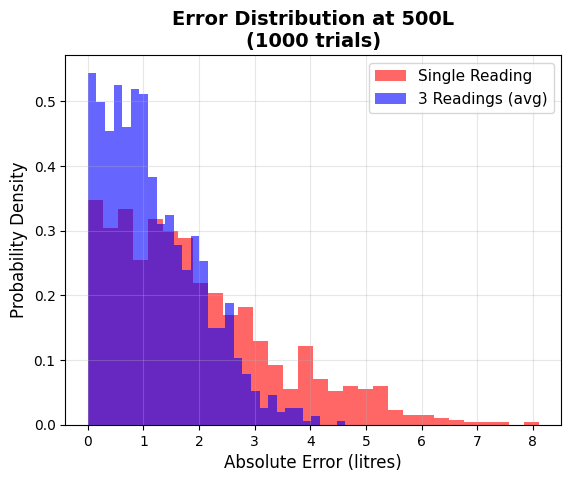

In [7]:
#Cube Error Multiple Trials Plot

n_trials = 1000
single_errors_all_trials = []
multiple_errors_all_trials = []


test_volume = 500
test_depth = cube_dipstick_depths[np.where(target_volumes_litres == test_volume)[0][0]]



#repeats above 1000 times and averages them
for trial in range(n_trials):
    # Single reading
    single_depth = cube_simulate_readings(test_depth, 1, reading_error_cm)[0]
    single_volume = cube_calculate_volume_from_readings([single_depth], 1, l)[0]
    single_error = abs(single_volume - test_volume)
    single_errors_all_trials.append(single_error)

    # Multiple readings
    multiple_depths = cube_simulate_readings(test_depth, n_readings, reading_error_cm)
    average_depth = np.mean(multiple_depths)
    average_volume = cube_calculate_volume_from_readings([average_depth], 1, l)[0]
    multiple_error = abs(average_volume - test_volume)
    multiple_errors_all_trials.append(multiple_error)




plt.hist(single_errors_all_trials, bins=30, alpha=0.6, color='red', label='Single Reading', density=True)
plt.hist(multiple_errors_all_trials, bins=30, alpha=0.6, color='blue', label=f'{n_readings} Readings (avg)', density=True)
plt.xlabel('Absolute Error (litres)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(f'Error Distribution at {test_volume}L\n({n_trials} trials)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.savefig("Error_Distribution.pdf", format="pdf")
plt.grid(True, alpha=0.3)

DIPSTICK CALIBRATION:
  50L |  16.79 cm
 100L |  24.29 cm
 150L |  30.32 cm
 200L |  35.63 cm
 250L |  40.49 cm
 300L |  45.07 cm
 350L |  49.46 cm
 400L |  53.71 cm
 450L |  57.89 cm
 500L |  62.04 cm
 550L |  66.18 cm
 600L |  70.36 cm
 650L |  74.61 cm
 700L |  79.00 cm
 750L |  83.58 cm
 800L |  88.44 cm
 850L |  93.75 cm
 900L |  99.78 cm
 950L | 107.28 cm
1000L | 124.07 cm


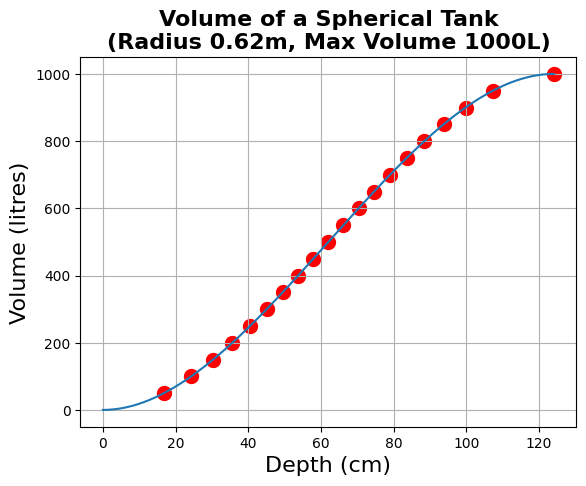

In [8]:
#Sphere Dipstick Callibrationn


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
import scipy.stats


target_total_volume_m3 = 1.0
r_sphere = (target_total_volume_m3 * 3 / (4 * np.pi))**(1/3)


n = np.linspace(0.0, 2 * r_sphere, 1000)

def sphere_volume(h, r):
    h = np.clip(h, 0, 2*r)
    return (1/3) * np.pi * (h**2) * (3*r - h)

a = np.zeros(1000)
for i in range(1000):

    a[i] = sphere_volume(n[i], r_sphere)

sphere_depth_from_volume = interp1d(a, n, bounds_error=False, fill_value="extrapolate") #



target_volumes = np.arange(50, 1001, 50) / 1000
sphere_dipstick_depths = sphere_depth_from_volume(target_volumes)


# calibration table
print("DIPSTICK CALIBRATION:")
for vol, depth in zip(range(50, 1001, 50), sphere_dipstick_depths):
    print(f"{vol:4}L | {depth*100:6.2f} cm")


# Plot
plt.plot(n*100, a*1000)

plt.scatter(sphere_dipstick_depths*100, target_volumes*1000, color='red', s=100)
plt.title(f"Volume of a Spherical Tank\n(Radius {r_sphere:.2f}m, Max Volume {target_total_volume_m3*1000:.0f}L)",fontsize=16,fontweight='bold')
plt.xlabel('Depth (cm)',fontsize=16)
plt.ylabel('Volume (litres)',fontsize=16)
plt.grid(True)
plt.savefig("dipstick_calibration_spherical.pdf", format="pdf")
plt.show()

In [10]:
#Sphere Dipstick Error

target_volumes_litres = np.arange(50, 1001, 50)
target_volumes = np.arange(50, 1001, 50) / 1000


# Reading error: ±0.5 cm in depth measurement
reading_error_cm = 0.5
reading_error_m = reading_error_cm / 100


print(f"\nAssuming dipstick reading error of ±{reading_error_cm} cm:\n")
print(f"{'Volume':>10} | {'Depth':>10} | {'ΔV (litres)':>15} | {'% Error':>10}")
print("-" * 52)

sphere_volume_errors = []
for vol, depth in zip(target_volumes_litres, sphere_dipstick_depths ):

    V_plus = sphere_volume(depth + reading_error_m, r_sphere) * 1000
    V_minus = sphere_volume(depth - reading_error_m, r_sphere) * 1000
    error_litres = max(abs(V_plus - vol), abs(V_minus - vol))
    error_percent = (error_litres / vol) * 100
    sphere_volume_errors.append(error_litres)
    print(f"{vol:>10.0f}L | {depth*100:>9.2f}cm | ±{error_litres:>12.2f} | {error_percent:>9.2f}%")


Assuming dipstick reading error of ±0.5 cm:

    Volume |      Depth |     ΔV (litres) |    % Error
----------------------------------------------------
        50L |     16.79cm | ±        2.86 |      5.73%
       100L |     24.29cm | ±        3.84 |      3.84%
       150L |     30.32cm | ±        4.49 |      2.99%
       200L |     35.63cm | ±        4.97 |      2.48%
       250L |     40.49cm | ±        5.33 |      2.13%
       300L |     45.07cm | ±        5.61 |      1.87%
       350L |     49.46cm | ±        5.81 |      1.66%
       400L |     53.71cm | ±        5.94 |      1.49%
       450L |     57.89cm | ±        6.02 |      1.34%
       500L |     62.04cm | ±        6.04 |      1.21%
       550L |     66.18cm | ±        6.02 |      1.09%
       600L |     70.36cm | ±        5.94 |      0.99%
       650L |     74.61cm | ±        5.81 |      0.89%
       700L |     79.00cm | ±        5.61 |      0.80%
       750L |     83.58cm | ±        5.33 |      0.71%
       800L |     88.

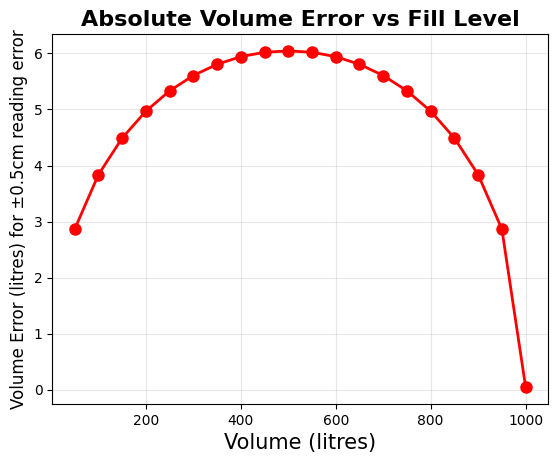

In [13]:
#Sphere Dipstick Absolute Error


plt.plot(target_volumes_litres, sphere_volume_errors, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Volume (litres)', fontsize=15)
plt.ylabel('Volume Error (litres) for ±0.5cm reading error', fontsize=12)
plt.title('Absolute Volume Error vs Fill Level', fontsize=16, fontweight='bold')
plt.savefig("Absolute_Volume_Error.pdf", format="pdf")
plt.grid(True, alpha=0.3)

In [16]:
#Sphere Error Multiple Trials

import scipy.stats as stats
n_readings = 3

#this simulates a human reading the dipstick accounting for random error in the reading
def sphere_simulate_readings(true_depth, n_readings, error_std):
    error_std_m = error_std / 100
    readings = np.random.normal(true_depth, error_std_m, n_readings)
    return readings

#converts the depth into a volume
def sphere_calculate_volume_from_readings(depth_readings, r, l):
    sphere_volumes = []
    for depth in depth_readings:

        if depth < 0:
            depth = 0
        if depth > 2*r:
            depth = 2*r
        vol = sphere_volume(depth, r_sphere) * 1000  # in litres
        sphere_volumes.append(vol)
    return np.array(sphere_volumes)


print("\nCOMPARISON: Single Reading vs Multiple Readings (Average)")
print("="*70)

np.random.seed(42)

single_reading_errors = []
multiple_reading_errors = []
confidence_intervals_95 = []

for true_vol, true_depth in zip(target_volumes_litres, sphere_dipstick_depths):

    single_depth = sphere_simulate_readings(true_depth, 1, reading_error_cm)[0]
    single_volume = sphere_calculate_volume_from_readings([single_depth], 1, l)[0]
    single_error = abs(single_volume - true_vol)
    single_reading_errors.append(single_error)


    multiple_depths = sphere_simulate_readings(true_depth, n_readings, reading_error_cm)
    average_depth = np.mean(multiple_depths)
    average_volume = sphere_calculate_volume_from_readings([average_depth], 1, l)[0]
    multiple_error = abs(average_volume - true_vol)
    multiple_reading_errors.append(multiple_error)


    all_volumes = sphere_calculate_volume_from_readings(multiple_depths, 1, l)


    ci_95 = stats.t.interval(0.95, len(all_volumes)-1,
                              loc=np.mean(all_volumes),
                              scale=stats.sem(all_volumes))
    ci_width = ci_95[1] - ci_95[0]
    confidence_intervals_95.append(ci_width)

print(f"{'Volume':>8} | {'True Depth':>12} | {'Single Error':>13} | {'Avg Error':>11} | {'Improvement':>12}")
print("-"*70)
for i, vol in enumerate(target_volumes_litres):
    improvement = (1 - multiple_reading_errors[i]/single_reading_errors[i]) * 100
    print(f"{vol:>8}L | {sphere_dipstick_depths[i]*100:>11.2f}cm | {single_reading_errors[i]:>12.2f}L | {multiple_reading_errors[i]:>10.2f}L | {improvement:>11.1f}%")


COMPARISON: Single Reading vs Multiple Readings (Average)
  Volume |   True Depth |  Single Error |   Avg Error |  Improvement
----------------------------------------------------------------------
      50L |       16.79cm |         1.41L |       1.93L |       -36.7%
     100L |       24.29cm |         0.89L |       2.70L |      -202.7%
     150L |       30.32cm |         2.09L |       0.58L |        72.5%
     200L |       35.63cm |         1.20L |       6.89L |      -474.8%
     250L |       40.49cm |         5.37L |       3.55L |        33.9%
     300L |       45.07cm |         8.23L |       2.95L |        64.2%
     350L |       49.46cm |         3.15L |       1.28L |        59.3%
     400L |       53.71cm |         3.56L |       1.90L |        46.7%
     450L |       57.89cm |         0.08L |       2.92L |     -3493.8%
     500L |       62.04cm |         1.26L |       6.23L |      -393.3%
     550L |       66.18cm |         4.44L |       0.49L |        88.9%
     600L |       70

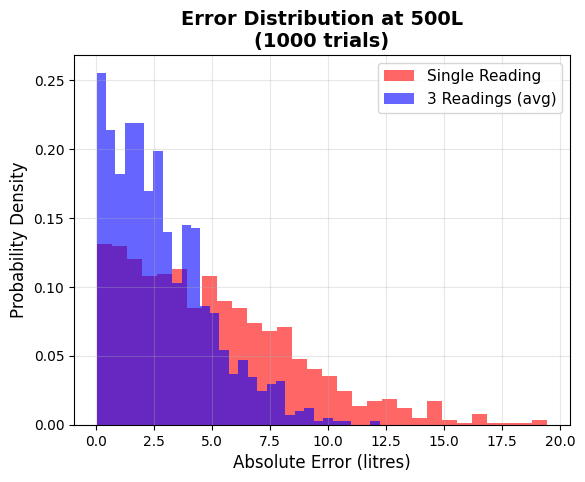

In [18]:
#Sphere Error Multiple Trials Plot

n_trials = 1000
single_errors_all_trials = []
multiple_errors_all_trials = []


test_volume = 500
test_depth = sphere_dipstick_depths[np.where(target_volumes_litres == test_volume)[0][0]]



#repeats above 1000 times and averages them
for trial in range(n_trials):
    # Single reading
    single_depth = sphere_simulate_readings(test_depth, 1, reading_error_cm)[0]
    single_volume = sphere_calculate_volume_from_readings([single_depth], 1, l)[0]
    single_error = abs(single_volume - test_volume)
    single_errors_all_trials.append(single_error)

    # Multiple readings
    multiple_depths = sphere_simulate_readings(test_depth, n_readings, reading_error_cm)
    average_depth = np.mean(multiple_depths)
    average_volume = sphere_calculate_volume_from_readings([average_depth], 1, l)[0]
    multiple_error = abs(average_volume - test_volume)
    multiple_errors_all_trials.append(multiple_error)




plt.hist(single_errors_all_trials, bins=30, alpha=0.6, color='red', label='Single Reading', density=True)
plt.hist(multiple_errors_all_trials, bins=30, alpha=0.6, color='blue', label=f'{n_readings} Readings (avg)', density=True)
plt.xlabel('Absolute Error (litres)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(f'Error Distribution at {test_volume}L\n({n_trials} trials)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.savefig("Error_Distribution.pdf", format="pdf")
plt.grid(True, alpha=0.3)